In [1]:
# Import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Face')

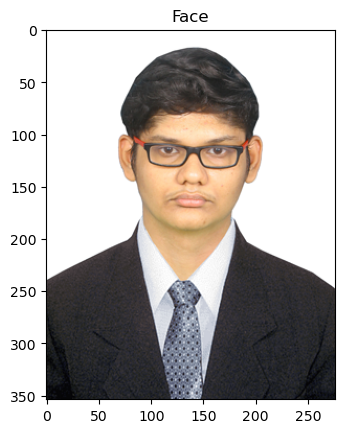

In [2]:
# Load the Face Image
faceImage = cv2.imread('23003973.png')
plt.imshow(faceImage[:,:,::-1]);plt.title("Face")


In [3]:
faceImage.shape

(354, 276, 3)

In [4]:
#resized_faceImage.shape
faceImage.shape

(354, 276, 3)

Text(0.5, 1.0, 'sunglass')

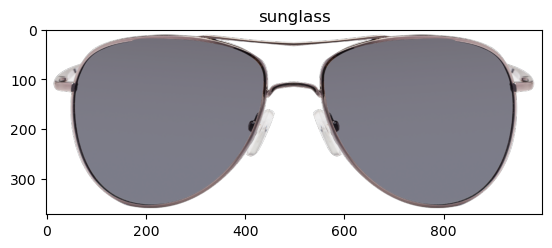

In [12]:
# Load the Sunglass image with Alpha channel
# (http://pluspng.com/sunglass-png-1104.html)
glassPNG = cv2.imread('glassPNG.png',-1)
glassPNG = glassPNG[:, :, [2, 1, 0, 3]]  
plt.imshow(glassPNG)   
plt.title("sunglass")

In [13]:
# Resize the image to fit over the eye region
glassPNG = cv2.resize(glassPNG,(190,25))
print("image Dimension ={}".format(glassPNG.shape))         

image Dimension =(25, 190, 4)


In [14]:
# Separate the Color and alpha channels
glassBGR = glassPNG[:,:,0:3]
glassMask1 = glassPNG[:,:,3]

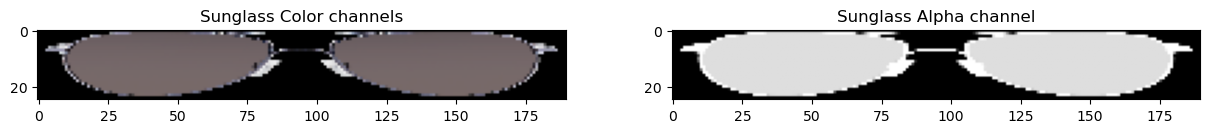

In [15]:
# Display the images for clarity
plt.figure(figsize=[15,15])
plt.subplot(121);plt.imshow(glassBGR[:,:,::-1]);plt.title('Sunglass Color channels');
plt.subplot(122);plt.imshow(glassMask1,cmap='gray');plt.title('Sunglass Alpha channel');

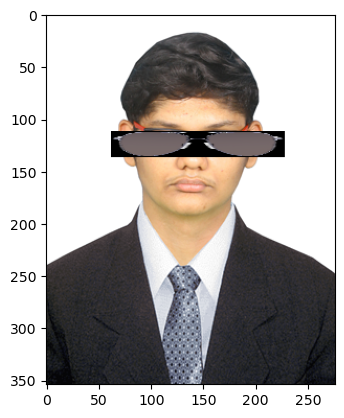

In [36]:

faceWithGlassesNaive = faceImage.copy()


h, w, _ = glassBGR.shape 


y_start, x_start = 112, 62 

faceWithGlassesNaive[y_start : y_start + h, x_start : x_start + w] = glassBGR

plt.imshow(faceWithGlassesNaive[...,::-1])
plt.show()

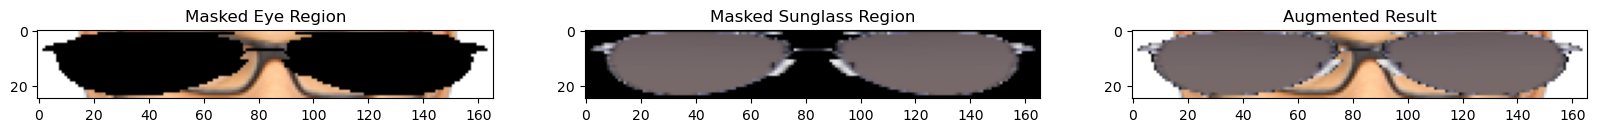

In [38]:

h, w, _ = glassBGR.shape 


glassMask1_fixed = cv2.resize(glassMask1, (w, h))
_, mask_bin = cv2.threshold(glassMask1_fixed, 1, 1, cv2.THRESH_BINARY)
glassMask = cv2.merge((mask_bin, mask_bin, mask_bin))


y_start, x_start = 108, 54 


eyeROI = faceImage[y_start : y_start + h, x_start : x_start + w]


maskedEye = cv2.multiply(eyeROI, (1 - glassMask))
maskedGlass = cv2.multiply(glassBGR, glassMask)


eyeRoiFinal = cv2.add(maskedEye, maskedGlass)


faceWithGlassesArithmetic = faceImage.copy()
faceWithGlassesArithmetic[y_start : y_start + h, x_start : x_start + w] = eyeRoiFinal


plt.figure(figsize=[20,10])
plt.subplot(131); plt.imshow(maskedEye[...,::-1]); plt.title("Masked Eye Region")
plt.subplot(132); plt.imshow(maskedGlass[...,::-1]); plt.title("Masked Sunglass Region")
plt.subplot(133); plt.imshow(eyeRoiFinal[...,::-1]); plt.title("Augmented Result")
plt.show()

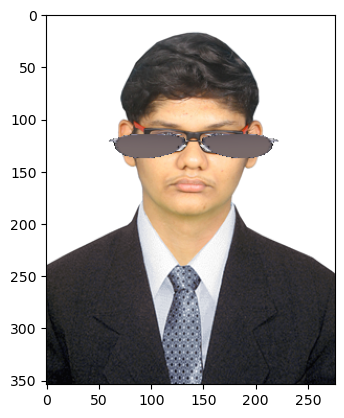

In [42]:
# FINAL ALIGNMENT TWEAK
# y=114 moves them up slightly to the actual eye line
# x=58 centers them better between the ears
y_s, x_s = 114, 58

# The rest of your arithmetic code stays exactly the same:
faceWithGlassesArithmetic = faceImage.copy()
eyeROI = faceWithGlassesArithmetic[y_s : y_s+h, x_s : x_s+w]

maskedEye = cv2.multiply(eyeROI, (1 - glassMask))
maskedGlass = cv2.multiply(glassBGR, glassMask)
eyeRoiFinal = cv2.add(maskedEye, maskedGlass)

faceWithGlassesArithmetic[y_s : y_s+h, x_s : x_s+w] = eyeRoiFinal

plt.imshow(faceWithGlassesArithmetic[...,::-1])
plt.show()